# Stability: kernel width sigma (10 degree mosaicity sample)

The reconstruction of `texture_tomography/domains_mosaicity_10p0deg/textomo_adaptive.ipynb`
(adaptive basis, unregularised nonnegative FISTA-Huber, field-of-view support) for a range of
widths sigma of the Gaussian kernel around every basis orientation, everything else fixed (the
same basis orientations, the same number of iterations).

Evaluation: 1. IPF-Z maps, 2. misorientation maps to the ground truth, 3. mean / median
misorientation, 4. grain and subgrain boundaries with statistics, 5. the differences between the
reconstructions, 6. data versus prediction. Reconstructions, figures and tables go to `processed/stability/<sample>/sigma/`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from simtools import paths, stability


def panel_axes(n, ncols=5, size=4.0):
    """A grid of image axes for n panels, without ticks; unused axes are hidden."""
    nrows = -(-n // ncols)
    fig, ax = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows), squeeze=False)
    for a in ax.ravel():
        a.axis("off")
    return fig, ax.ravel()


def heatmap(ax, df, title, fmt="{:.2f}"):
    im = ax.imshow(df.values, cmap="viridis")
    ax.set_xticks(range(len(df.columns)), df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(df.index)), df.index)
    for i in range(len(df.index)):
        for j in range(len(df.columns)):
            v = df.values[i, j]
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8,
                    color="white" if v < 0.5 * np.nanmax(df.values) else "black")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

## Parameters

In [2]:
SAMPLE = "domains_mosaicity_10p0deg"
SIGMAS_DEG = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0]  # swept
NITER = 200                 # as in textomo_adaptive.ipynb
HUBER_DELTA = 100.0         # as in textomo_adaptive.ipynb
RERUN = False               # False: reuse reconstructions already in OUT (made with NITER iterations)

UPSAMPLE = 4                # display grid: UPSAMPLE x 99 pixels per side (as in the figure notebooks)
TOP_K = 24                  # orientations per voxel entering the weighted medoid
MISORI_VMAX = 40.0          # deg, top of the misorientation colour scale (log scale)
GB_THRESHOLD = 4.0          # deg, KAM at or above this: grain boundary
SUBGRAIN_THRESHOLD = 0.5    # deg, KAM at or above this: subgrain boundary
OMEGA_INDEX = 90            # data vs prediction: rotation step (of 360, 0.5 deg each)
TRANSLATION_INDEX = 51      # data vs prediction: translation of the single frame (of 103; 51 = centre)
RING = None                 # ring of the eta profiles; None: the strongest ring of the frame
ZOOM_ETA = 15.0             # deg, half width of the zoom on the strongest peak of the profiles
IMAGE_GAMMA = 0.5           # colour scale of the ring x eta images: intensity ** IMAGE_GAMMA (weak, broad peaks visible)

OUT = os.path.join(paths.PROCESS, "stability", SAMPLE, "sigma")
os.makedirs(OUT, exist_ok=True)

values = np.array(SIGMAS_DEG)
labels = [f"σ = {s}°" for s in SIGMAS_DEG]
files = {label: os.path.join(OUT, f"reconstruction_sigma{s}.h5") for label, s in zip(labels, SIGMAS_DEG)}
PARAM_LABEL, PARAM_SCALE = "kernel width σ (°)", "log"

## Reconstructions
One operator per sigma (the pole figures of the basis functions change with sigma, and so does
the step size 1/L). The relative weighted residual is ||w (A x - y)|| / ||w y||.

In [3]:
todo = [s for s, f in zip(SIGMAS_DEG, files.values())
        if RERUN or not os.path.exists(f) or stability.read_attrs(f)[0]["niter"] != NITER]
if todo:
    problem = stability.load_problem(SAMPLE)
    for s in todo:
        rec = stability.Reconstructor(problem, s)
        coeffs, objective, residual, seconds = rec.run(NITER, HUBER_DELTA)
        stability.save_reconstruction(os.path.join(OUT, f"reconstruction_sigma{s}.h5"), coeffs, rec.grid_mats,
                                      objective, sample=SAMPLE, sigma_deg=s, niter=NITER,
                                      huber_delta=HUBER_DELTA, residual=residual, fista_time_s=seconds)
        print(f"sigma {s} deg: K = {rec.K}, L = {rec.L:.4e}, PF matrix {rec.op.pf_mode}, "
              f"relative weighted residual {residual:.5f}, {seconds:.0f} s")
        rec.free()
        del rec, coeffs
    del problem

sigma 2.0 deg: K = 3025, L = 1.1272e+12, PF matrix sparse, relative weighted residual 0.91214, 52 s


sigma 3.0 deg: K = 3025, L = 6.3941e+11, PF matrix sparse, relative weighted residual 0.95047, 71 s


sigma 4.0 deg: K = 3025, L = 4.6666e+11, PF matrix dense, relative weighted residual 0.96793, 175 s


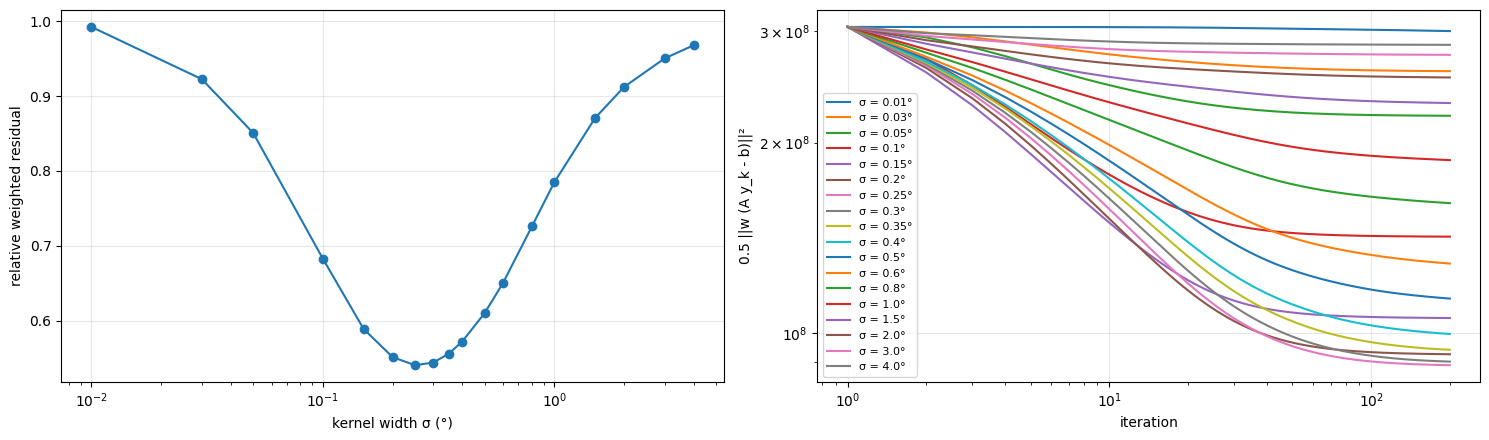

,sigma (deg),iterations,relative weighted residual,FISTA time (s)
run,,,,
σ = 0.01°,0.01,200,0.99245,28.59588
σ = 0.03°,0.03,200,0.92262,47.74931
σ = 0.05°,0.05,200,0.85072,47.90745
σ = 0.1°,0.10,200,0.68279,48.80560
σ = 0.15°,0.15,200,0.58885,48.90044
σ = 0.2°,0.20,200,0.55126,40.97455
σ = 0.25°,0.25,200,0.54039,49.56893
σ = 0.3°,0.30,200,0.54394,47.77865
σ = 0.35°,0.35,200,0.55575,49.90821


In [4]:
runs, objectives = [], {}
for label, h5 in files.items():
    attrs, objectives[label] = stability.read_attrs(h5)
    runs.append({"run": label, "sigma (deg)": attrs["sigma_deg"], "iterations": attrs["niter"],
                 "relative weighted residual": attrs["residual"], "FISTA time (s)": attrs["fista_time_s"]})
runs = pd.DataFrame(runs).set_index("run")

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].plot(values, runs["relative weighted residual"].values, "o-")
ax[0].set_xlabel(PARAM_LABEL)
ax[0].set_xscale(PARAM_SCALE)
ax[0].set_ylabel("relative weighted residual")
for label, obj in objectives.items():
    ax[1].plot(np.arange(1, len(obj) + 1), obj, label=label)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("iteration")
ax[1].set_ylabel("0.5 ||w (A y_k - b)||²")
ax[1].legend(fontsize=8)
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "convergence.png"), dpi=100, bbox_inches="tight")
plt.show()
runs.round(5)

## Orientation maps
Per voxel, the weighted medoid of the `TOP_K` largest coefficients, upsampled `UPSAMPLE` x onto the
display grid of the ground truth (as in `visualization/<sample>/figure_panels.ipynb`). The medoids
are cached in `OUT` and recomputed when a reconstruction file changes.

In [5]:
grid = stability.display_grid(SAMPLE, UPSAMPLE)
maps = {}
for label, h5 in files.items():
    print(label)
    maps[label] = stability.medoid_map(h5, grid, os.path.join(OUT, f"medoid_{Path(h5).stem}.npz"), top_k=TOP_K)

σ = 0.01°


  weighted medoid of 7511 pixels in 6 s
σ = 0.03°


  weighted medoid of 7511 pixels in 6 s
σ = 0.05°


  weighted medoid of 7511 pixels in 6 s
σ = 0.1°


  weighted medoid of 7511 pixels in 6 s
σ = 0.15°


...

  weighted medoid of 7511 pixels in 4 s
σ = 1.5°


  weighted medoid of 7511 pixels in 4 s
σ = 2.0°


  weighted medoid of 7511 pixels in 5 s
σ = 3.0°


  weighted medoid of 7511 pixels in 5 s
σ = 4.0°


  weighted medoid of 7511 pixels in 6 s


## 1. IPF-Z maps

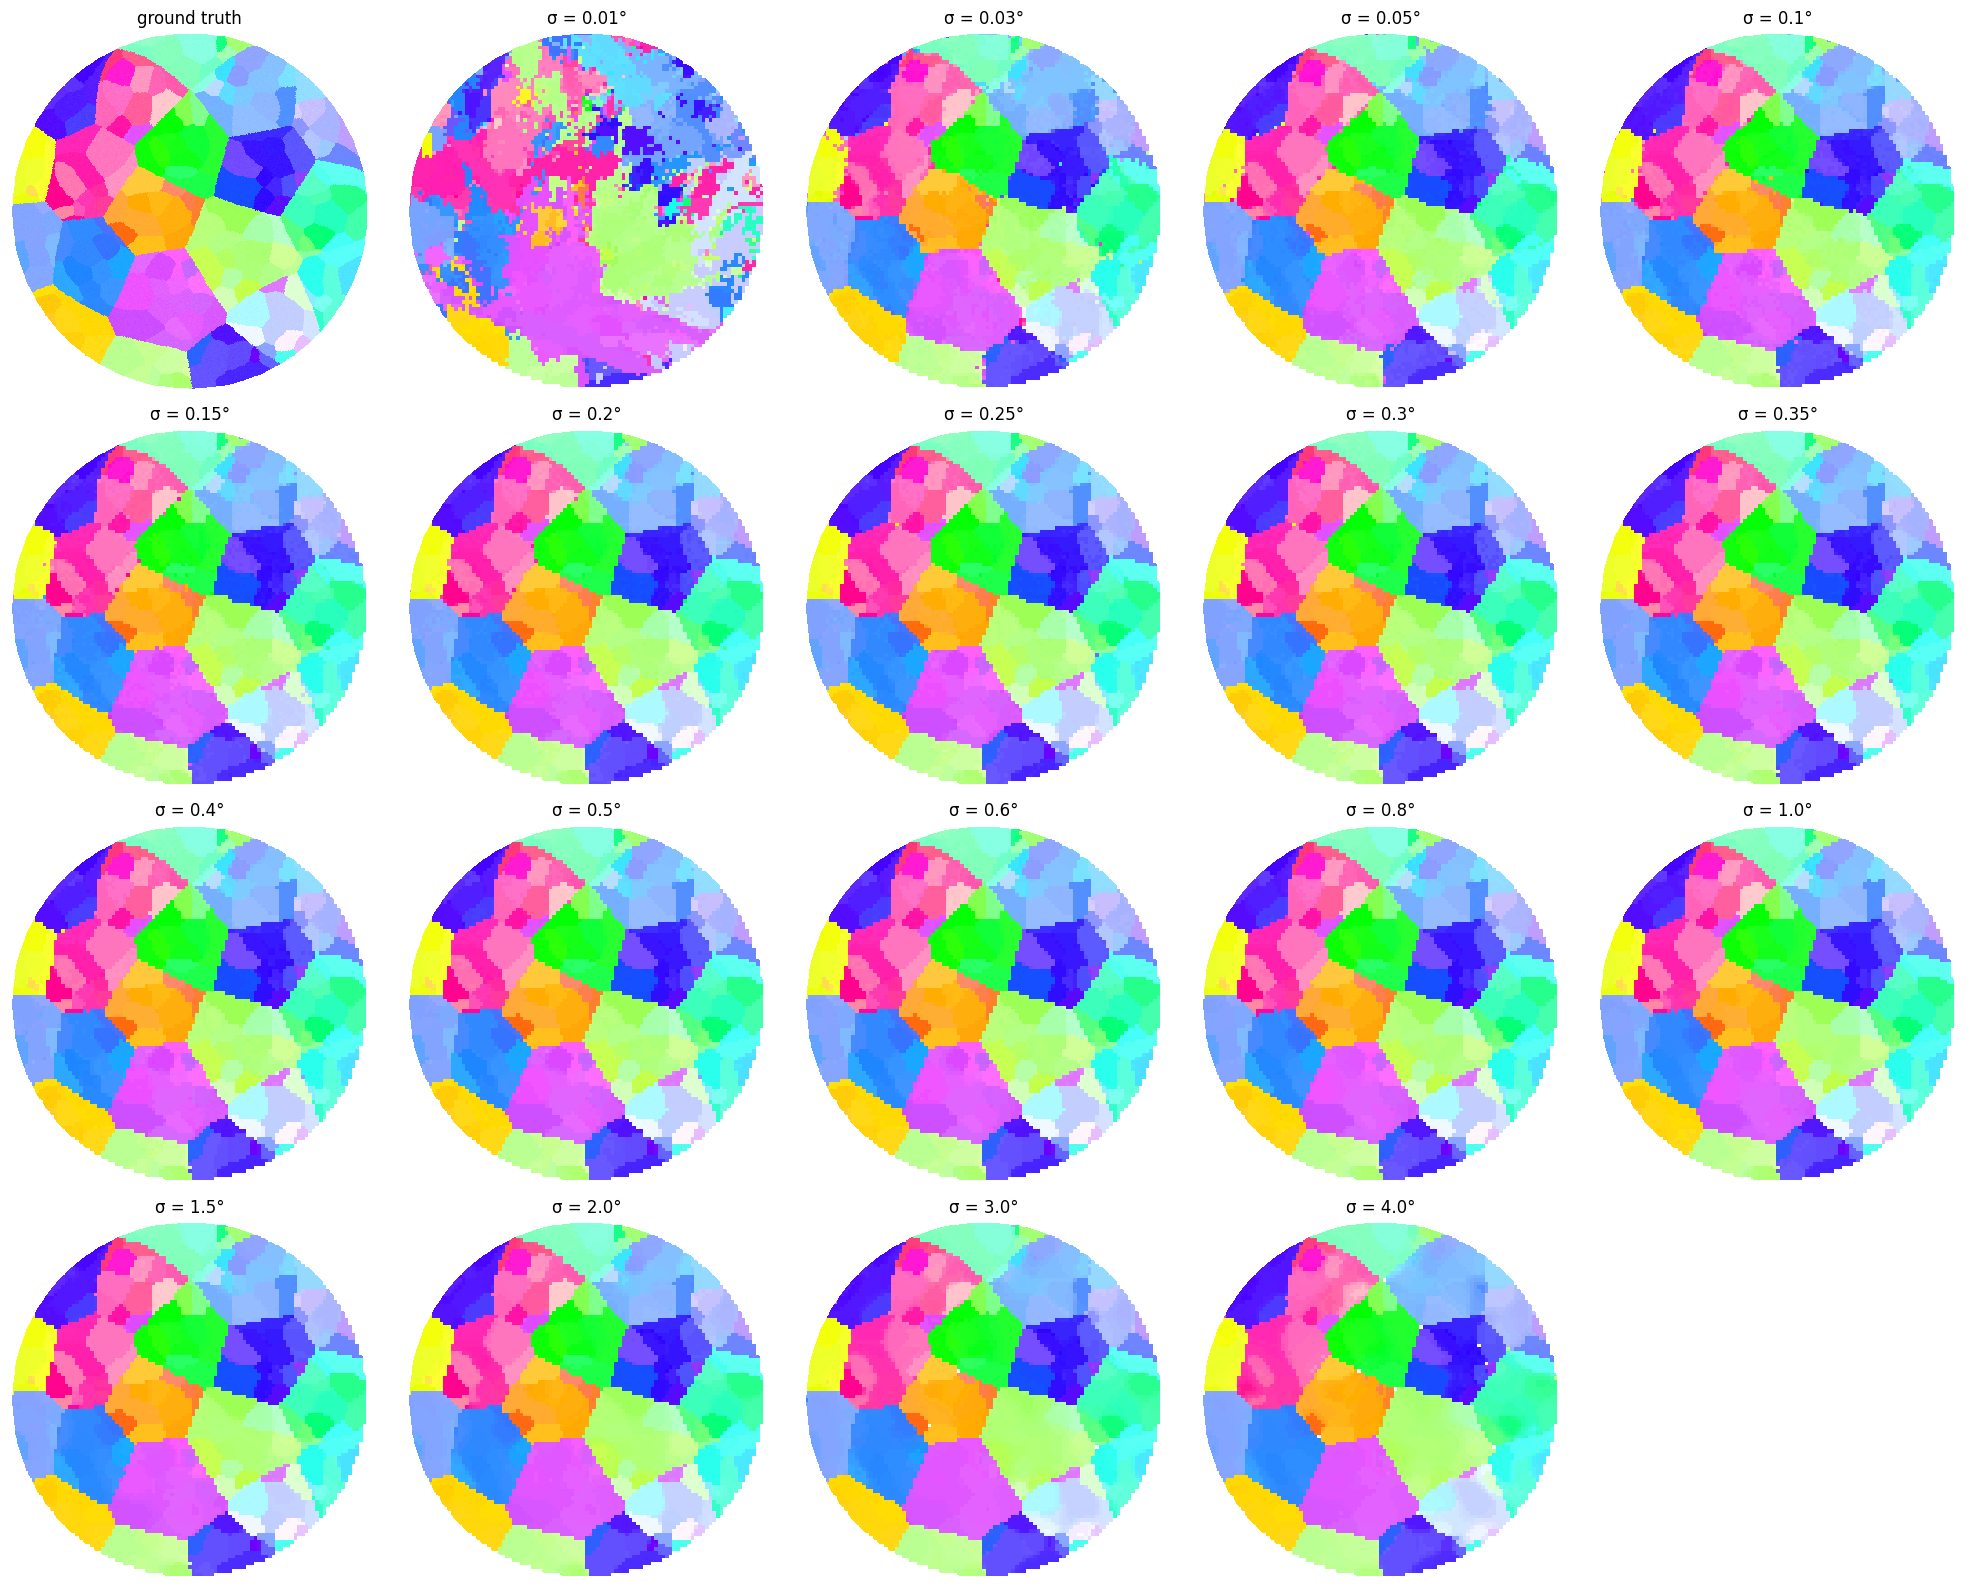

In [6]:
fig, ax = panel_axes(len(maps) + 1)
ax[0].imshow(stability.ipf_image(grid["gt"], grid["gt_valid"]), interpolation="nearest")
ax[0].set_title("ground truth")
for a, (label, (ori, valid)) in zip(ax[1:], maps.items()):
    a.imshow(stability.ipf_image(ori, valid), interpolation="nearest")
    a.set_title(label)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "ipf_z.png"), dpi=100, bbox_inches="tight")
plt.show()

## 2.-3. Misorientation to the ground truth
Maps on a log colour scale up to `MISORI_VMAX`, and the mean / median / 90th percentile over the
sample.

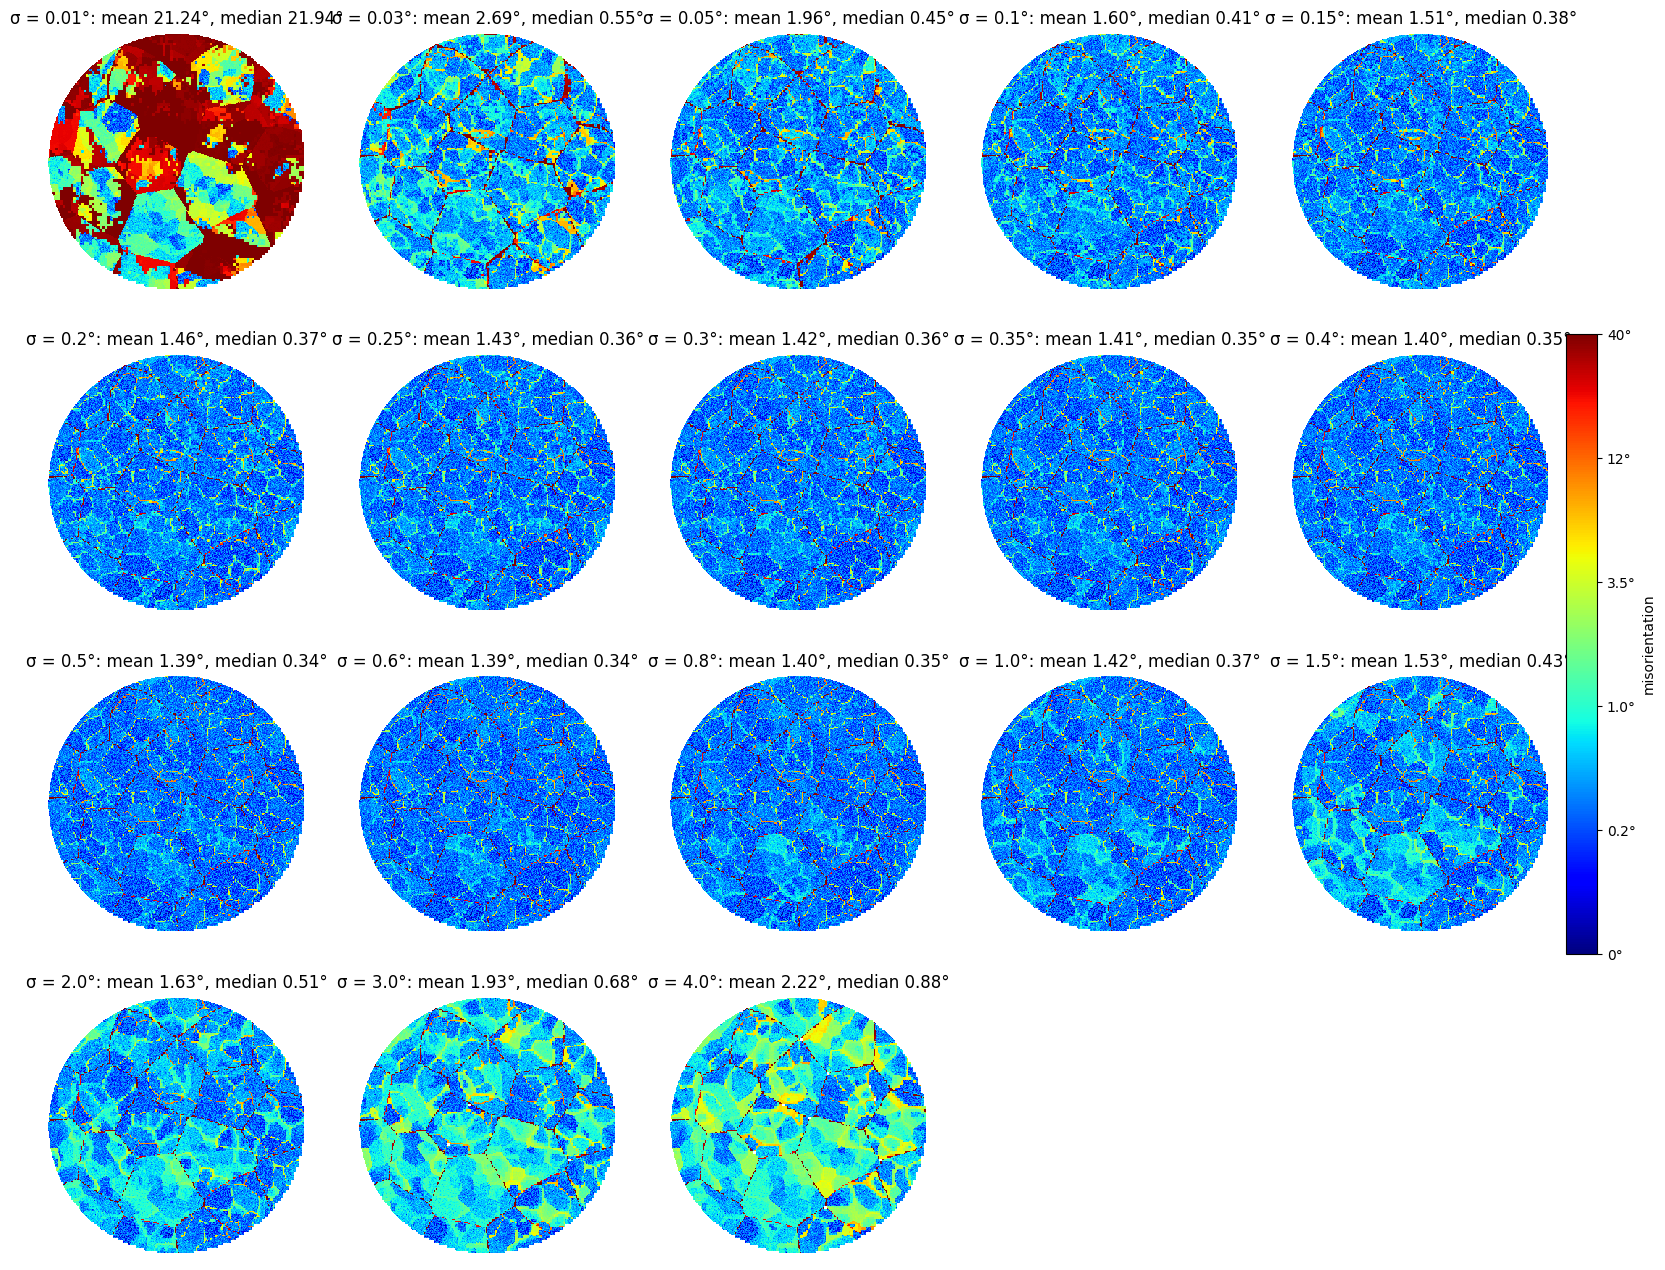

,mean (deg),median (deg),90th percentile (deg),fraction > 5 deg
map,,,,
σ = 0.01°,21.237,21.938,48.472,0.583
σ = 0.03°,2.686,0.554,4.041,0.088
σ = 0.05°,1.957,0.452,1.899,0.057
σ = 0.1°,1.597,0.406,1.104,0.045
σ = 0.15°,1.507,0.381,0.964,0.043
σ = 0.2°,1.460,0.368,0.897,0.041
σ = 0.25°,1.432,0.363,0.845,0.040
σ = 0.3°,1.421,0.358,0.800,0.040
σ = 0.35°,1.407,0.352,0.761,0.039


In [7]:
misori, misori_table = stability.misorientation_to_ground_truth(grid, maps)

fig, ax = panel_axes(len(maps))
for a, (label, m) in zip(ax, misori.items()):
    a.imshow(stability.misorientation_image(m, maps[label][1], MISORI_VMAX), interpolation="nearest")
    a.set_title(f"{label}: mean {np.nanmean(m):.2f}°, median {np.nanmedian(m):.2f}°")
stability.misorientation_colorbar(fig, list(ax), MISORI_VMAX)
fig.savefig(os.path.join(OUT, "misorientation.png"), dpi=100, bbox_inches="tight")
plt.show()

misori_table.round(3)

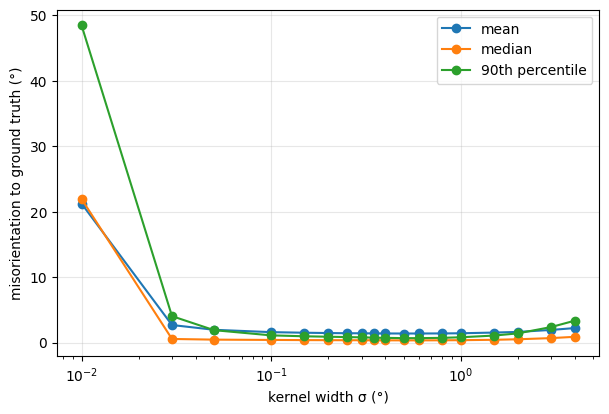

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for col in ["mean (deg)", "median (deg)", "90th percentile (deg)"]:
    ax.plot(values, misori_table[col].values, "o-", label=col.replace(" (deg)", ""))
ax.set_xlabel(PARAM_LABEL)
ax.set_ylabel("misorientation to ground truth (°)")
ax.set_xscale(PARAM_SCALE)
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(os.path.join(OUT, "misorientation_statistics.png"), dpi=100, bbox_inches="tight")
plt.show()

## 4. Grain and subgrain boundaries
Boundary pixels: kernel average misorientation (4 neighbours) of at least `GB_THRESHOLD` (grain) or
`SUBGRAIN_THRESHOLD` (subgrain), inside the sample eroded by one voxel; the ground truth is median
filtered first. Overlays: reconstruction dark red (grain) / light red (subgrain), ground truth dark
blue / light blue, mixed colours where both coincide.

Statistics, in micrometres: **deviation** = distance from each reconstructed boundary pixel to the
nearest ground-truth boundary of the same kind (spurious boundaries raise it); **gt → rec** = distance
from each ground-truth boundary pixel to the nearest reconstructed one (missing boundaries raise it).

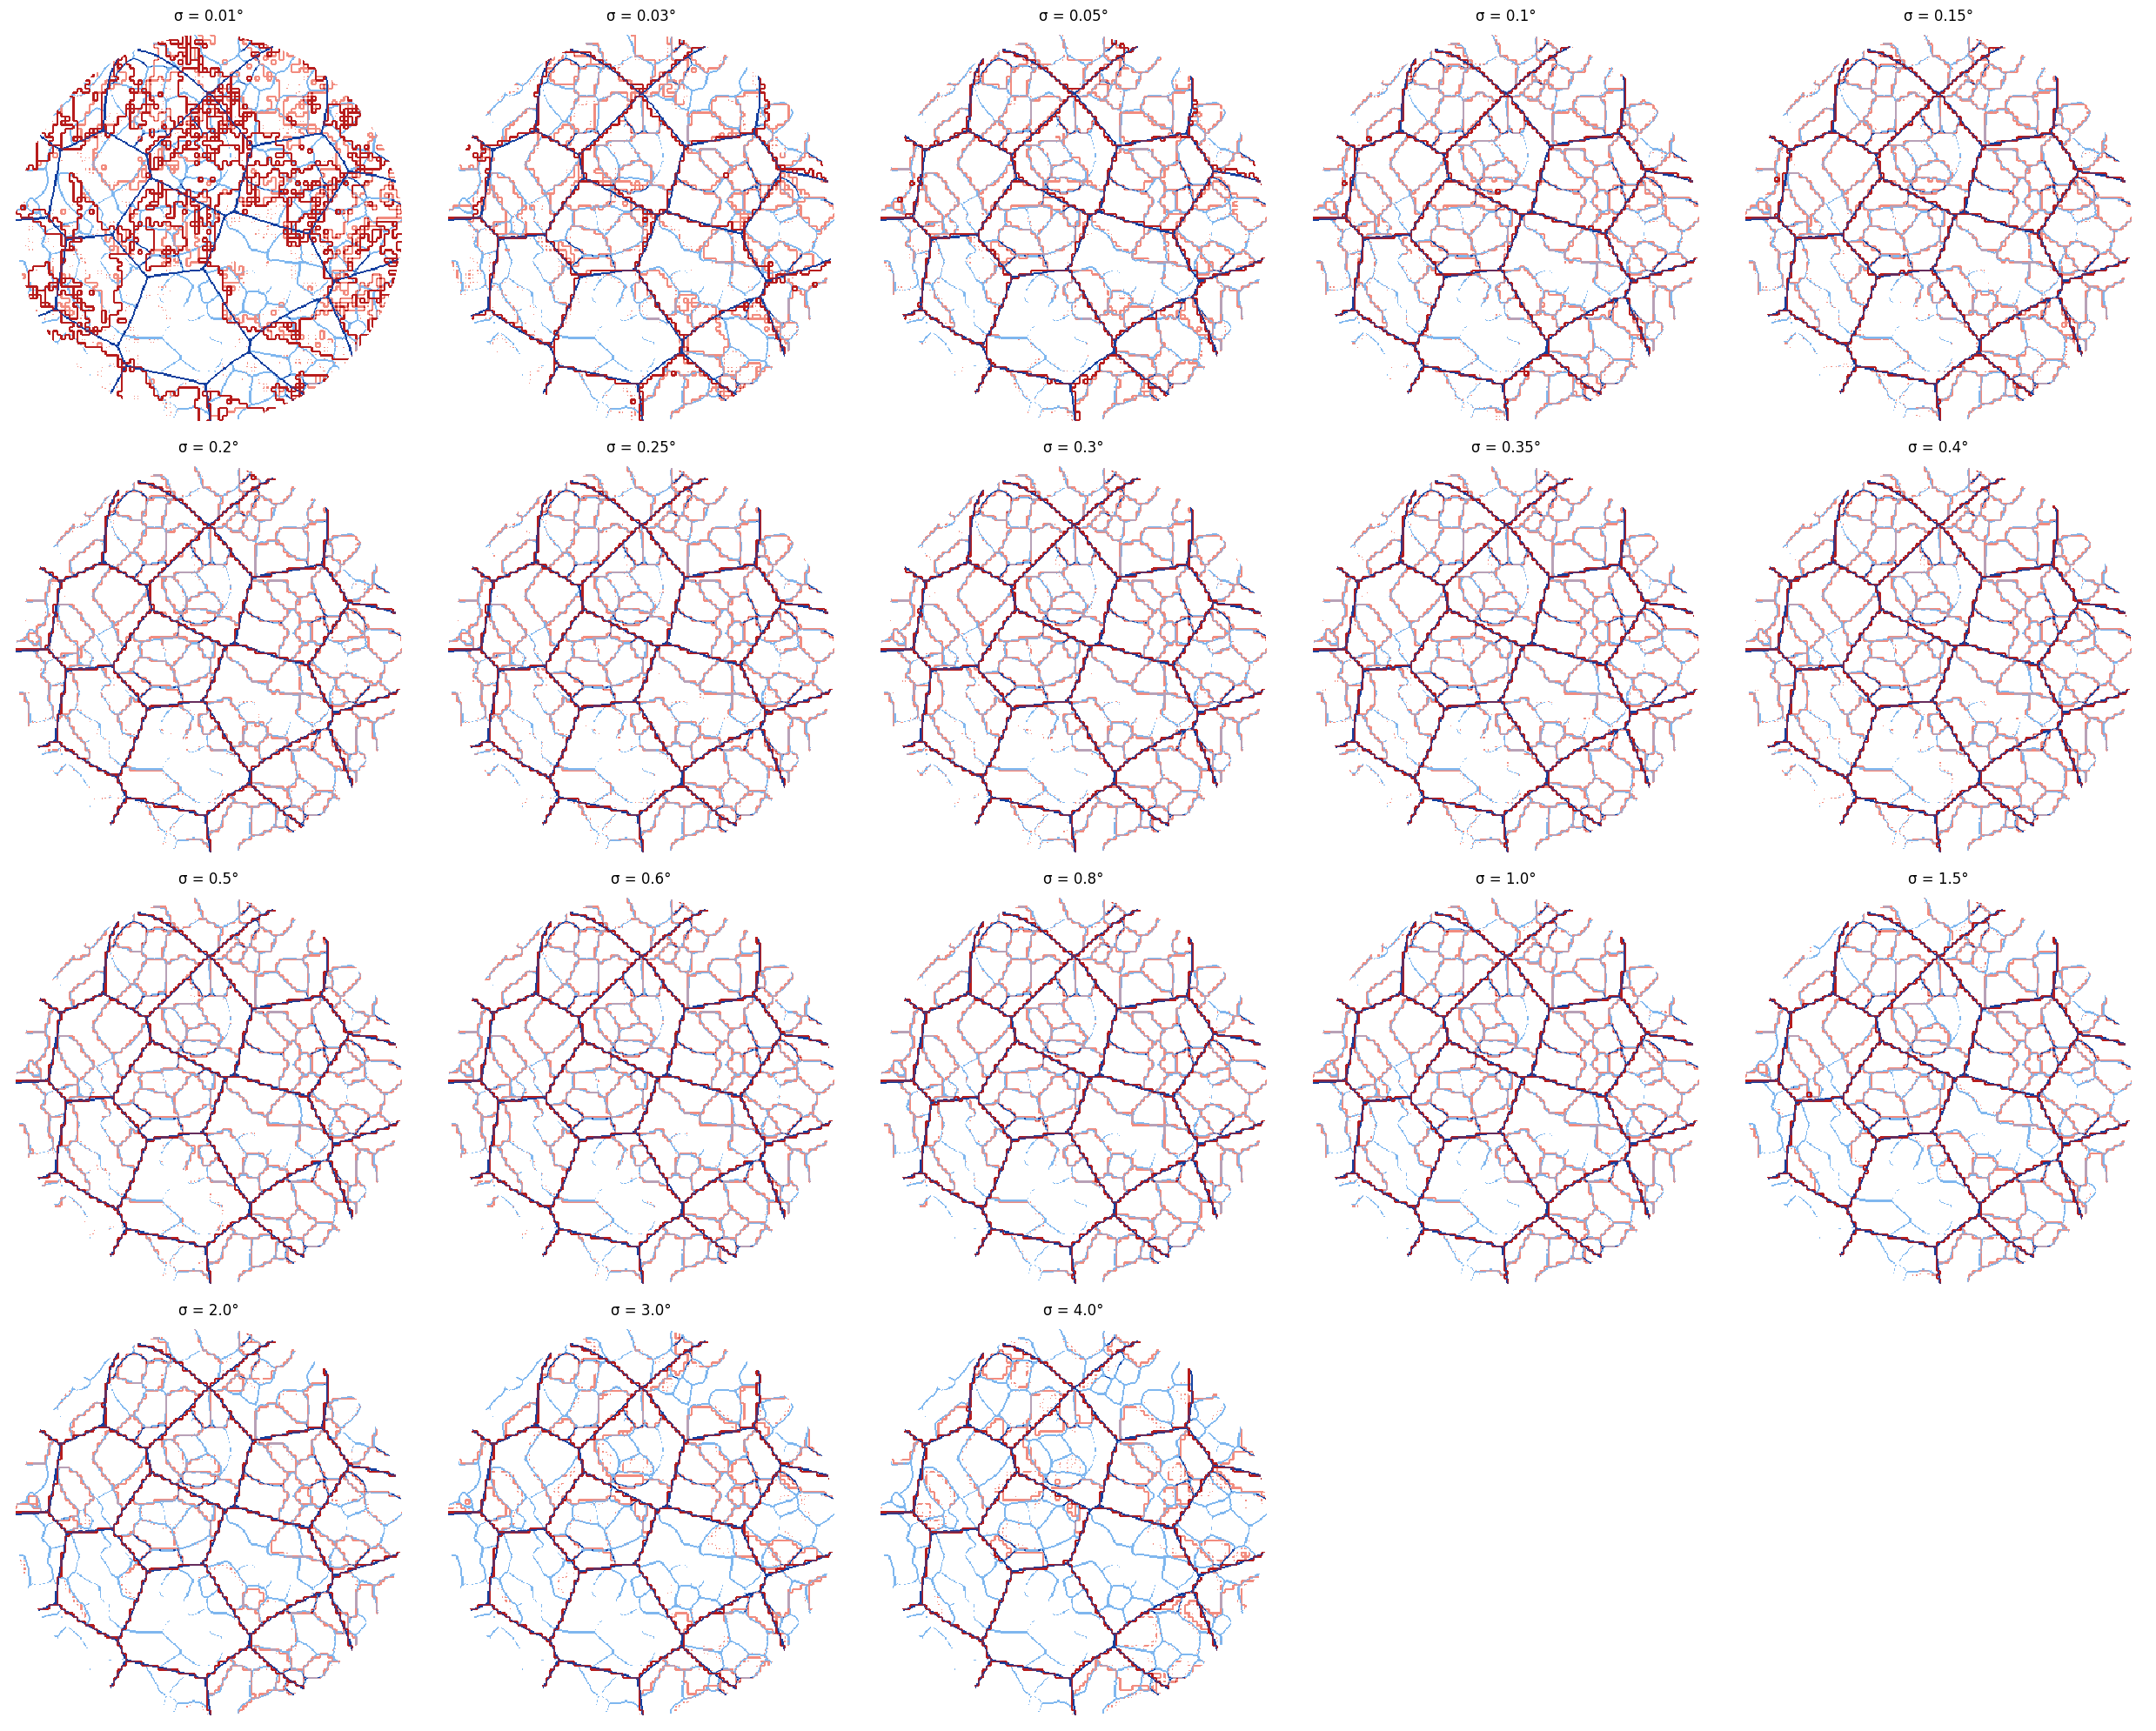

,map,boundary,pixels,pixels (gt),mean deviation (um),median deviation (um),mean gt -> rec (um),median gt -> rec (um)
0,σ = 0.01°,grain,17973,4782,0.2671,0.2178,0.1131,0.0721
1,σ = 0.01°,subgrain,26785,14420,0.0903,0.0721,0.0702,0.0361
2,σ = 0.03°,grain,6528,4782,0.0501,0.0255,0.0334,0.0255
3,σ = 0.03°,subgrain,18386,14420,0.0352,0.0255,0.0328,0.0255
4,σ = 0.05°,grain,6150,4782,0.0301,0.0255,0.0239,0.0255
5,σ = 0.05°,subgrain,17908,14420,0.0232,0.0255,0.0215,0.0000
6,σ = 0.1°,grain,5863,4782,0.0206,0.0255,0.0194,0.0000
7,σ = 0.1°,subgrain,17791,14420,0.0183,0.0255,0.0156,0.0000
8,σ = 0.15°,grain,5824,4782,0.0186,0.0255,0.0180,0.0000
9,σ = 0.15°,subgrain,17811,14420,0.0174,0.0255,0.0130,0.0000


In [9]:
gt_b, rec_b, boundary_table = stability.boundary_analysis(grid, maps, GB_THRESHOLD, SUBGRAIN_THRESHOLD)

fig, ax = panel_axes(len(maps), size=5)
for a, label in zip(ax, maps):
    a.imshow(stability.boundary_overlay(gt_b, rec_b[label]), interpolation="nearest")
    a.set_title(label)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "boundaries.png"), dpi=100, bbox_inches="tight")
plt.show()

boundary_table.round(4)

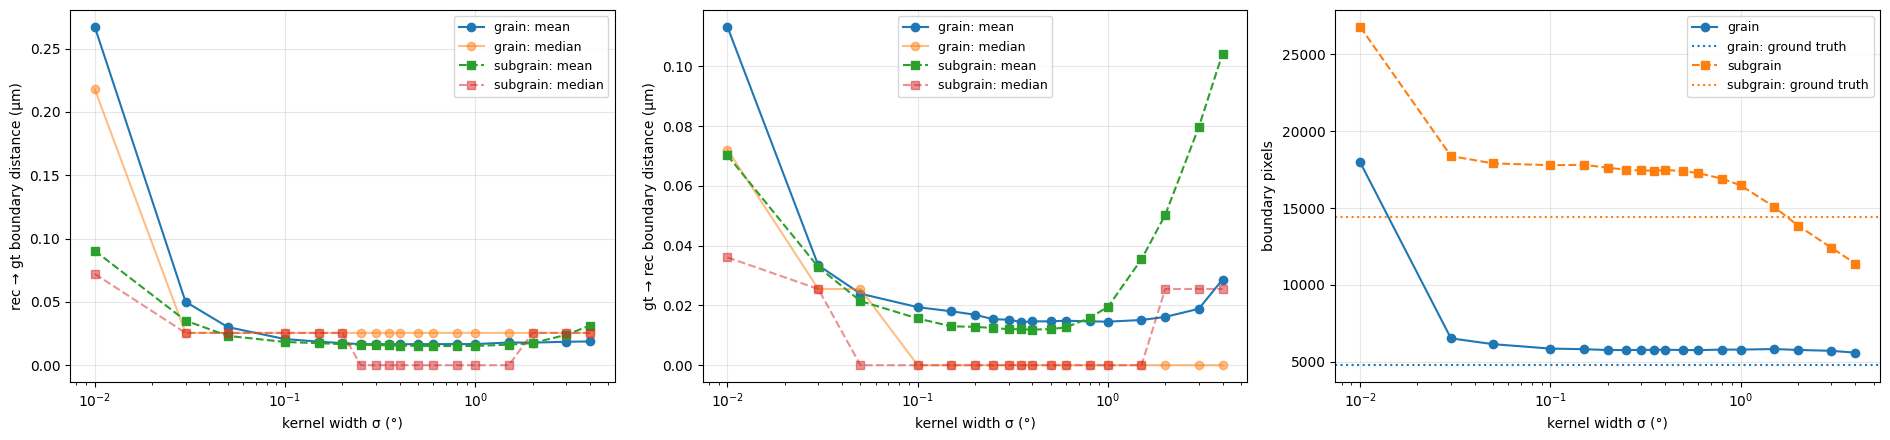

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(19, 4.5))
for kind, style in [("grain", "o-"), ("subgrain", "s--")]:
    t = boundary_table[boundary_table["boundary"] == kind]
    ax[0].plot(values, t["mean deviation (um)"].values, style, label=f"{kind}: mean")
    ax[0].plot(values, t["median deviation (um)"].values, style, alpha=0.5, label=f"{kind}: median")
    ax[1].plot(values, t["mean gt -> rec (um)"].values, style, label=f"{kind}: mean")
    ax[1].plot(values, t["median gt -> rec (um)"].values, style, alpha=0.5, label=f"{kind}: median")
    ax[2].plot(values, t["pixels"].values, style, label=kind)
    ax[2].axhline(t["pixels (gt)"].values[0], color=ax[2].lines[-1].get_color(), ls=":", label=f"{kind}: ground truth")
ax[0].set_ylabel("rec → gt boundary distance (µm)")
ax[1].set_ylabel("gt → rec boundary distance (µm)")
ax[2].set_ylabel("boundary pixels")
for a in ax:
    a.set_xlabel(PARAM_LABEL)
    a.set_xscale(PARAM_SCALE)
    a.legend(fontsize=9)
    a.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "boundary_statistics.png"), dpi=100, bbox_inches="tight")
plt.show()

## 5. Differences between the reconstructions
* mean / median misorientation between the medoid maps of every pair;
* the relative difference of the coefficients, ||x_row - x_col|| / ||x_col|| (the same basis orientations, but each coefficient is the weight of a kernel of different width, so this compares the representations rather than the textures; the medoid maps are the physically comparable quantity);
* misorientation maps between consecutive reconstructions in the sweep (same colour scale as above).

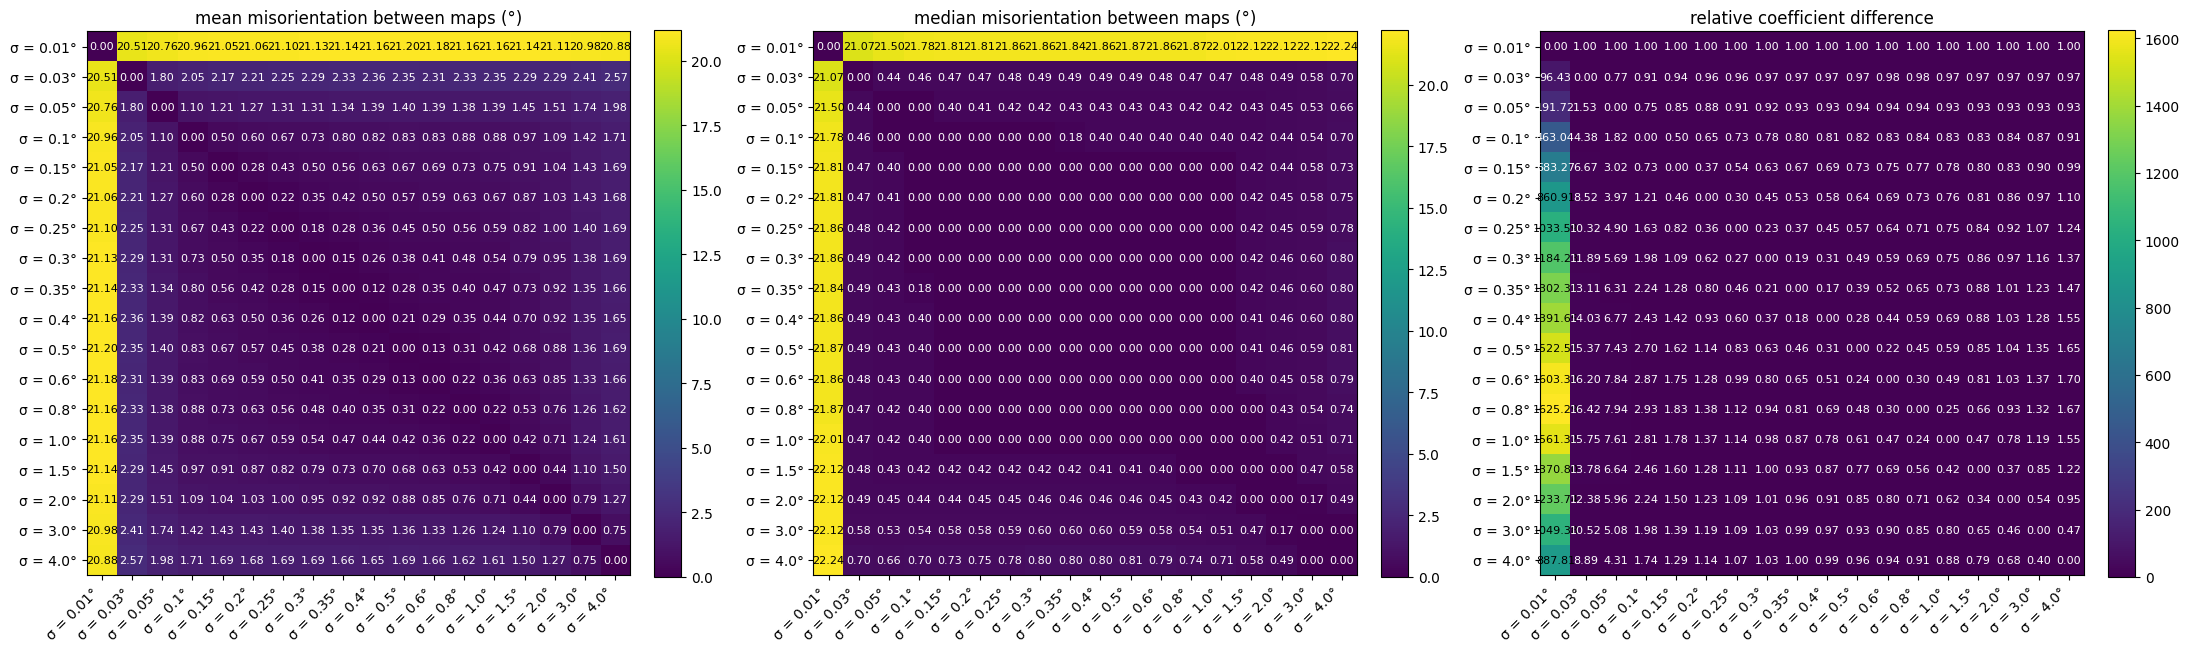

In [11]:
pair_mean, pair_median = stability.pairwise_misorientation(maps)
coeff_diff = stability.pairwise_coefficient_difference(files)

fig, ax = plt.subplots(1, 3, figsize=(22, 6.5))
heatmap(ax[0], pair_mean, "mean misorientation between maps (°)")
heatmap(ax[1], pair_median, "median misorientation between maps (°)")
heatmap(ax[2], coeff_diff, "relative coefficient difference")
plt.tight_layout()
fig.savefig(os.path.join(OUT, "pairwise_differences.png"), dpi=100, bbox_inches="tight")
plt.show()

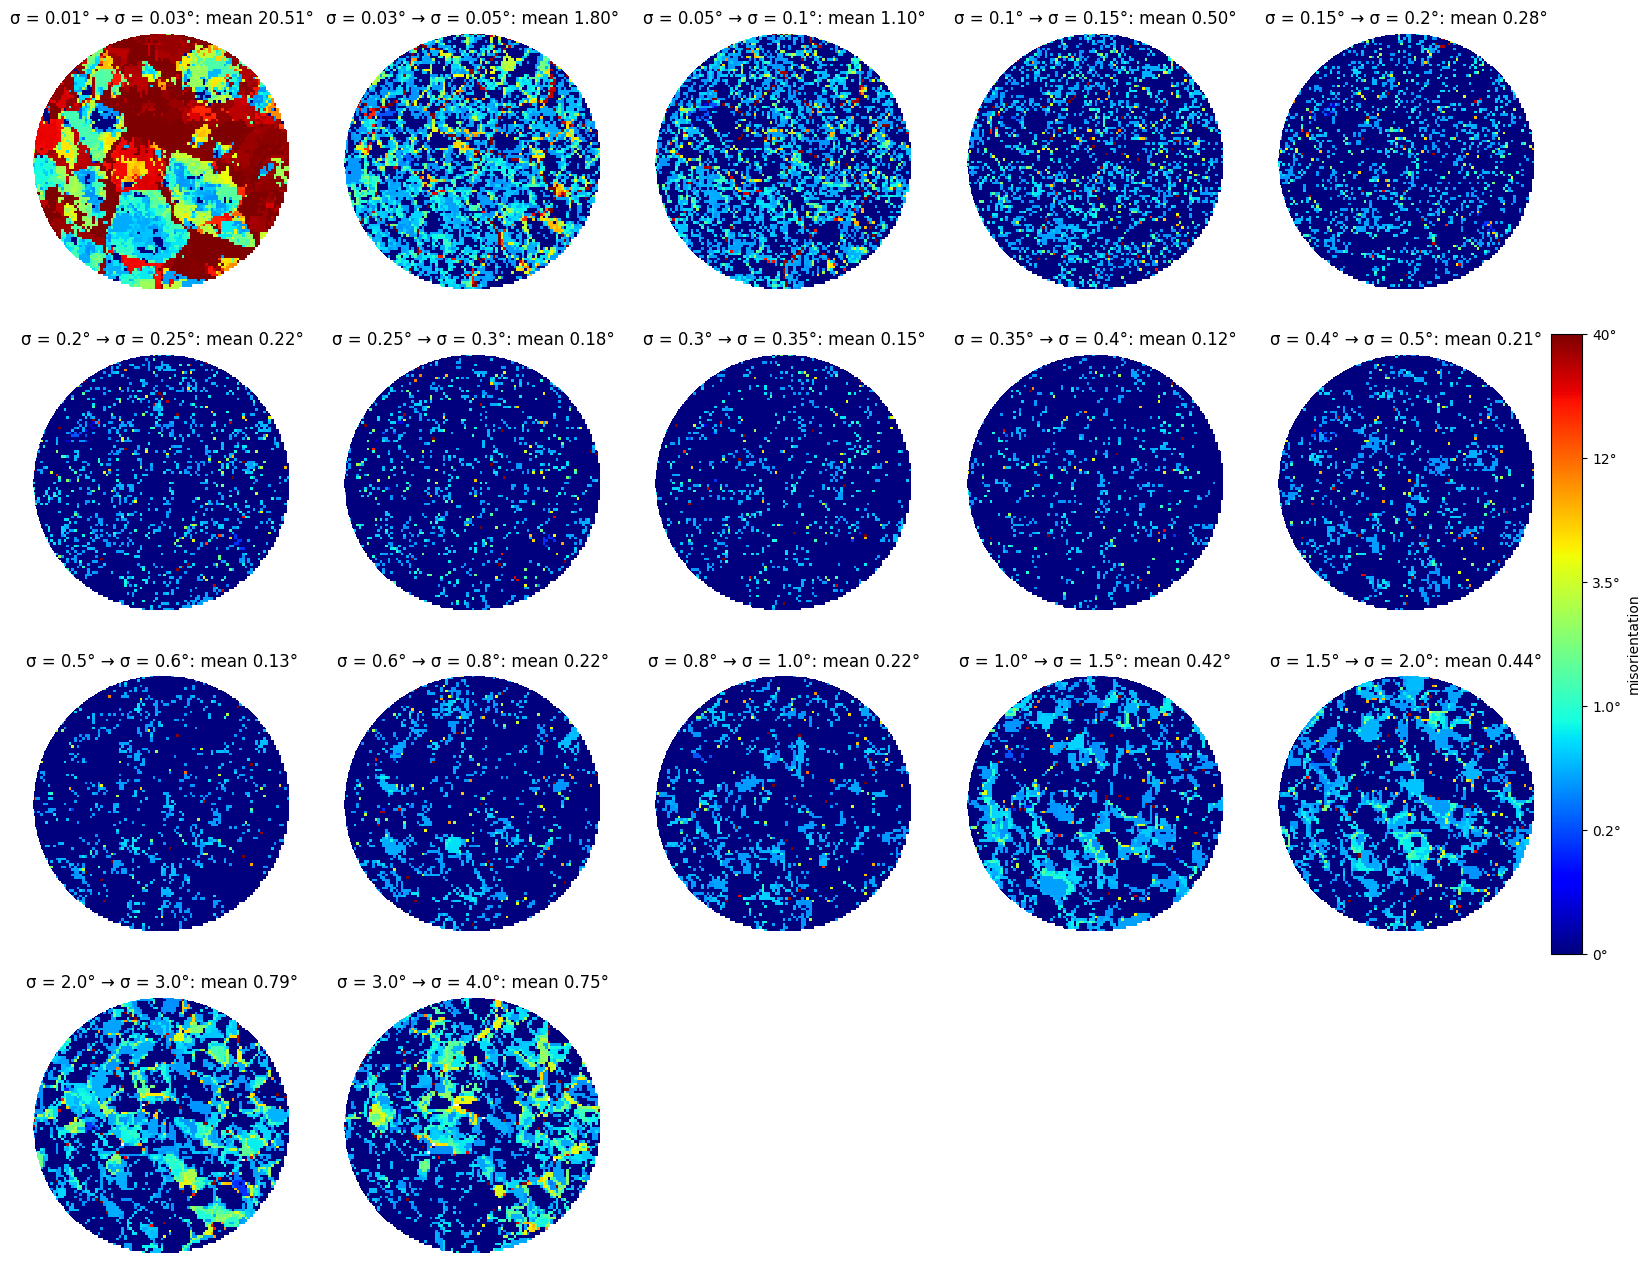

In [12]:
labels = list(maps)
fig, ax = panel_axes(len(labels) - 1)
for a, (prev, cur) in zip(ax, zip(labels[:-1], labels[1:])):
    both = maps[prev][1] & maps[cur][1]
    m = stability.figures.misorientation_map(maps[prev][0], maps[cur][0], both)
    a.imshow(stability.misorientation_image(m, both, MISORI_VMAX), interpolation="nearest")
    a.set_title(f"{prev} → {cur}: mean {np.nanmean(m):.2f}°")
stability.misorientation_colorbar(fig, list(ax), MISORI_VMAX)
fig.savefig(os.path.join(OUT, "consecutive_misorientation.png"), dpi=100, bbox_inches="tight")
plt.show()

## 6. Data versus prediction
The measured data next to the prediction A x of every reconstruction, as ring index versus eta: a
single detector frame (one rotation, one translation: `OMEGA_INDEX`, `TRANSLATION_INDEX`), and all
translations summed at that rotation; the panels of one figure share a colour scale (intensity ** `IMAGE_GAMMA`). The profiles below cut one
ring along eta (compare the widths of the predicted peaks with the measured ones, and with the orientation maps above); grey: eta bins with zero weight in the fit (along the rotation axis).
The predictions are computed on the GPU once and cached in `OUT`.

  σ = 0.01°: predicted in 2 s


  σ = 0.03°: predicted in 2 s


  σ = 0.05°: predicted in 2 s


  σ = 0.1°: predicted in 2 s


  σ = 0.15°: predicted in 2 s


...

  σ = 1.0°: predicted in 2 s


  σ = 1.5°: predicted in 2 s


  σ = 2.0°: predicted in 2 s


  σ = 3.0°: predicted in 2 s


  σ = 4.0°: predicted in 2 s


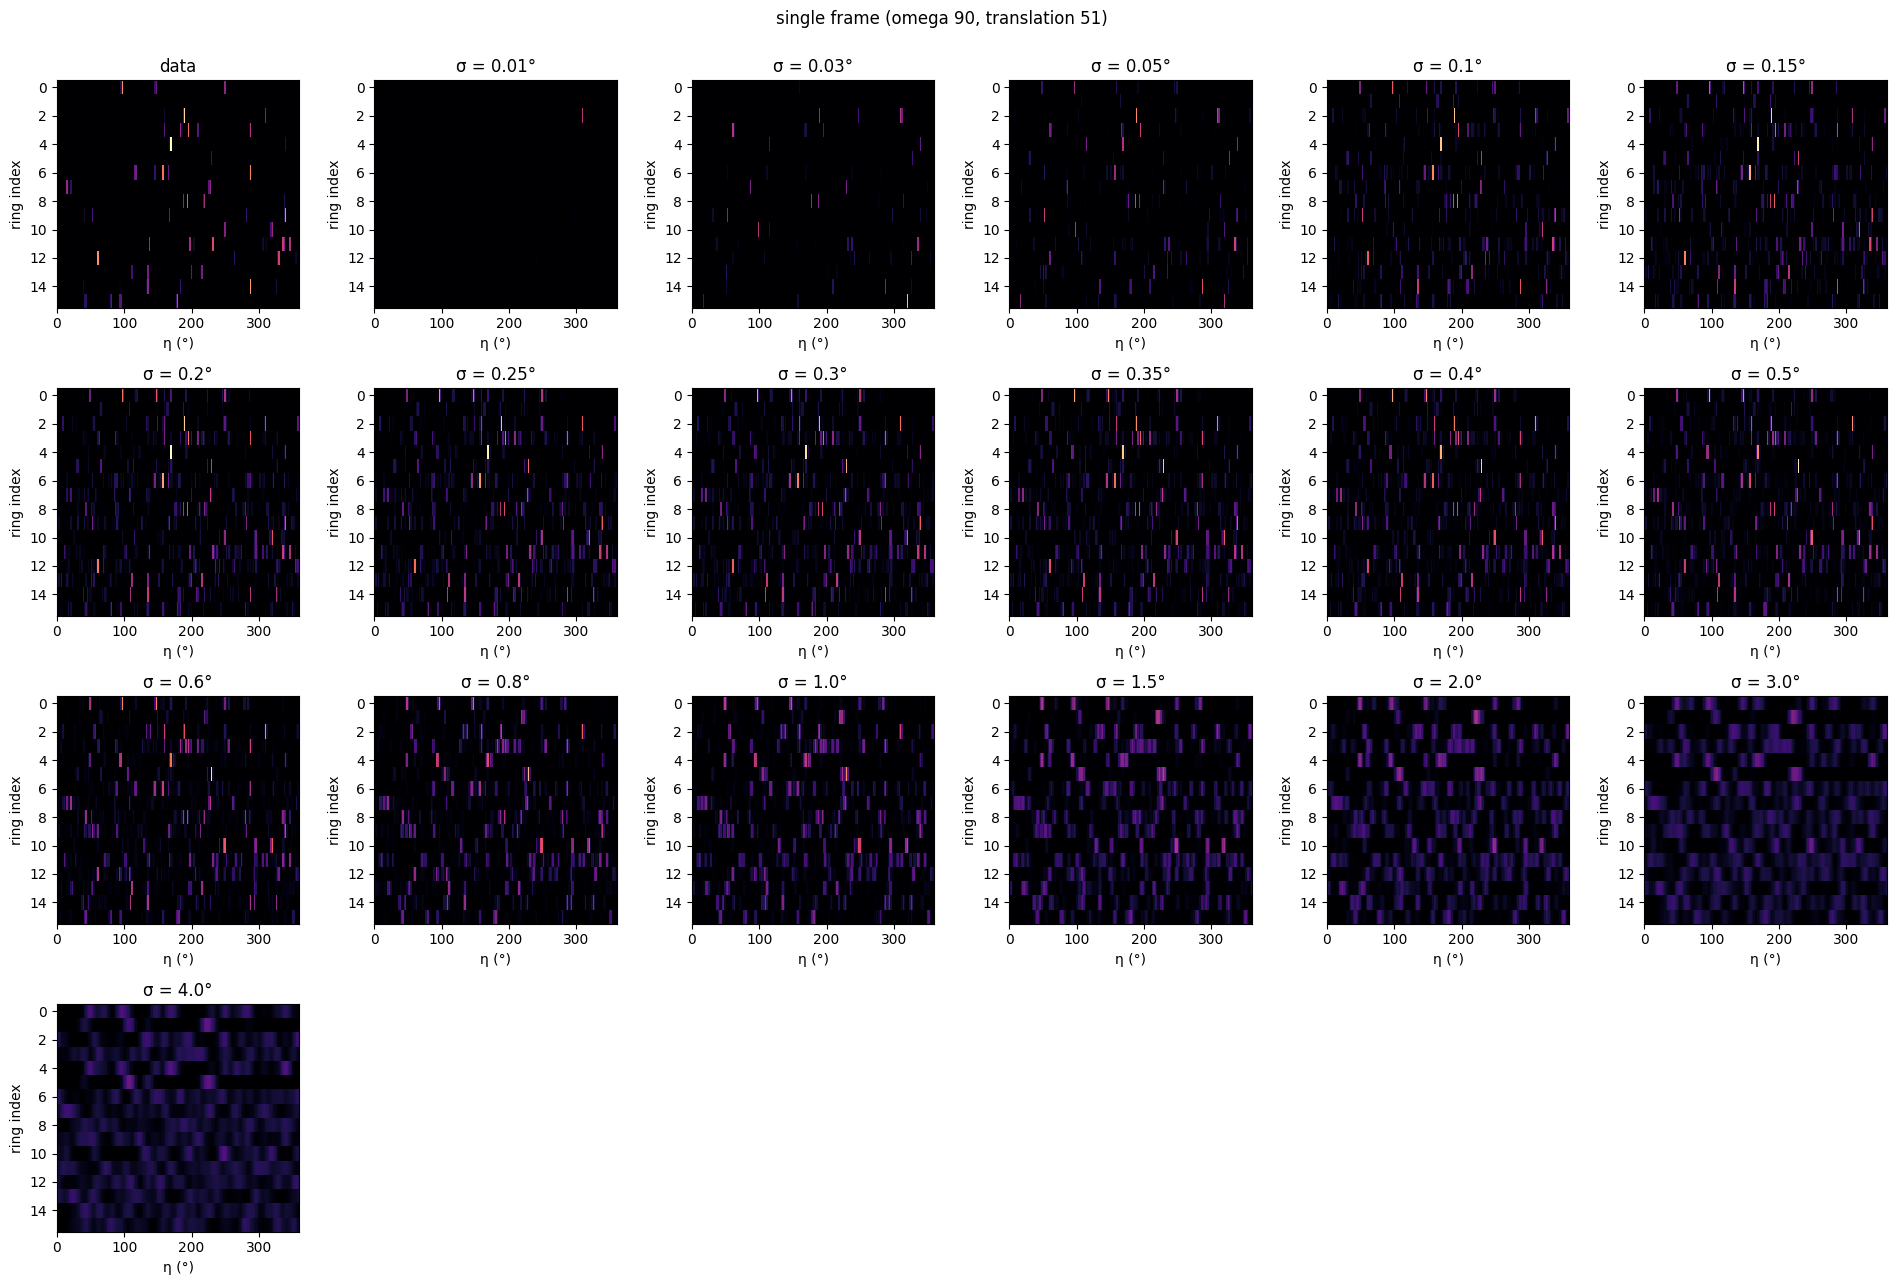

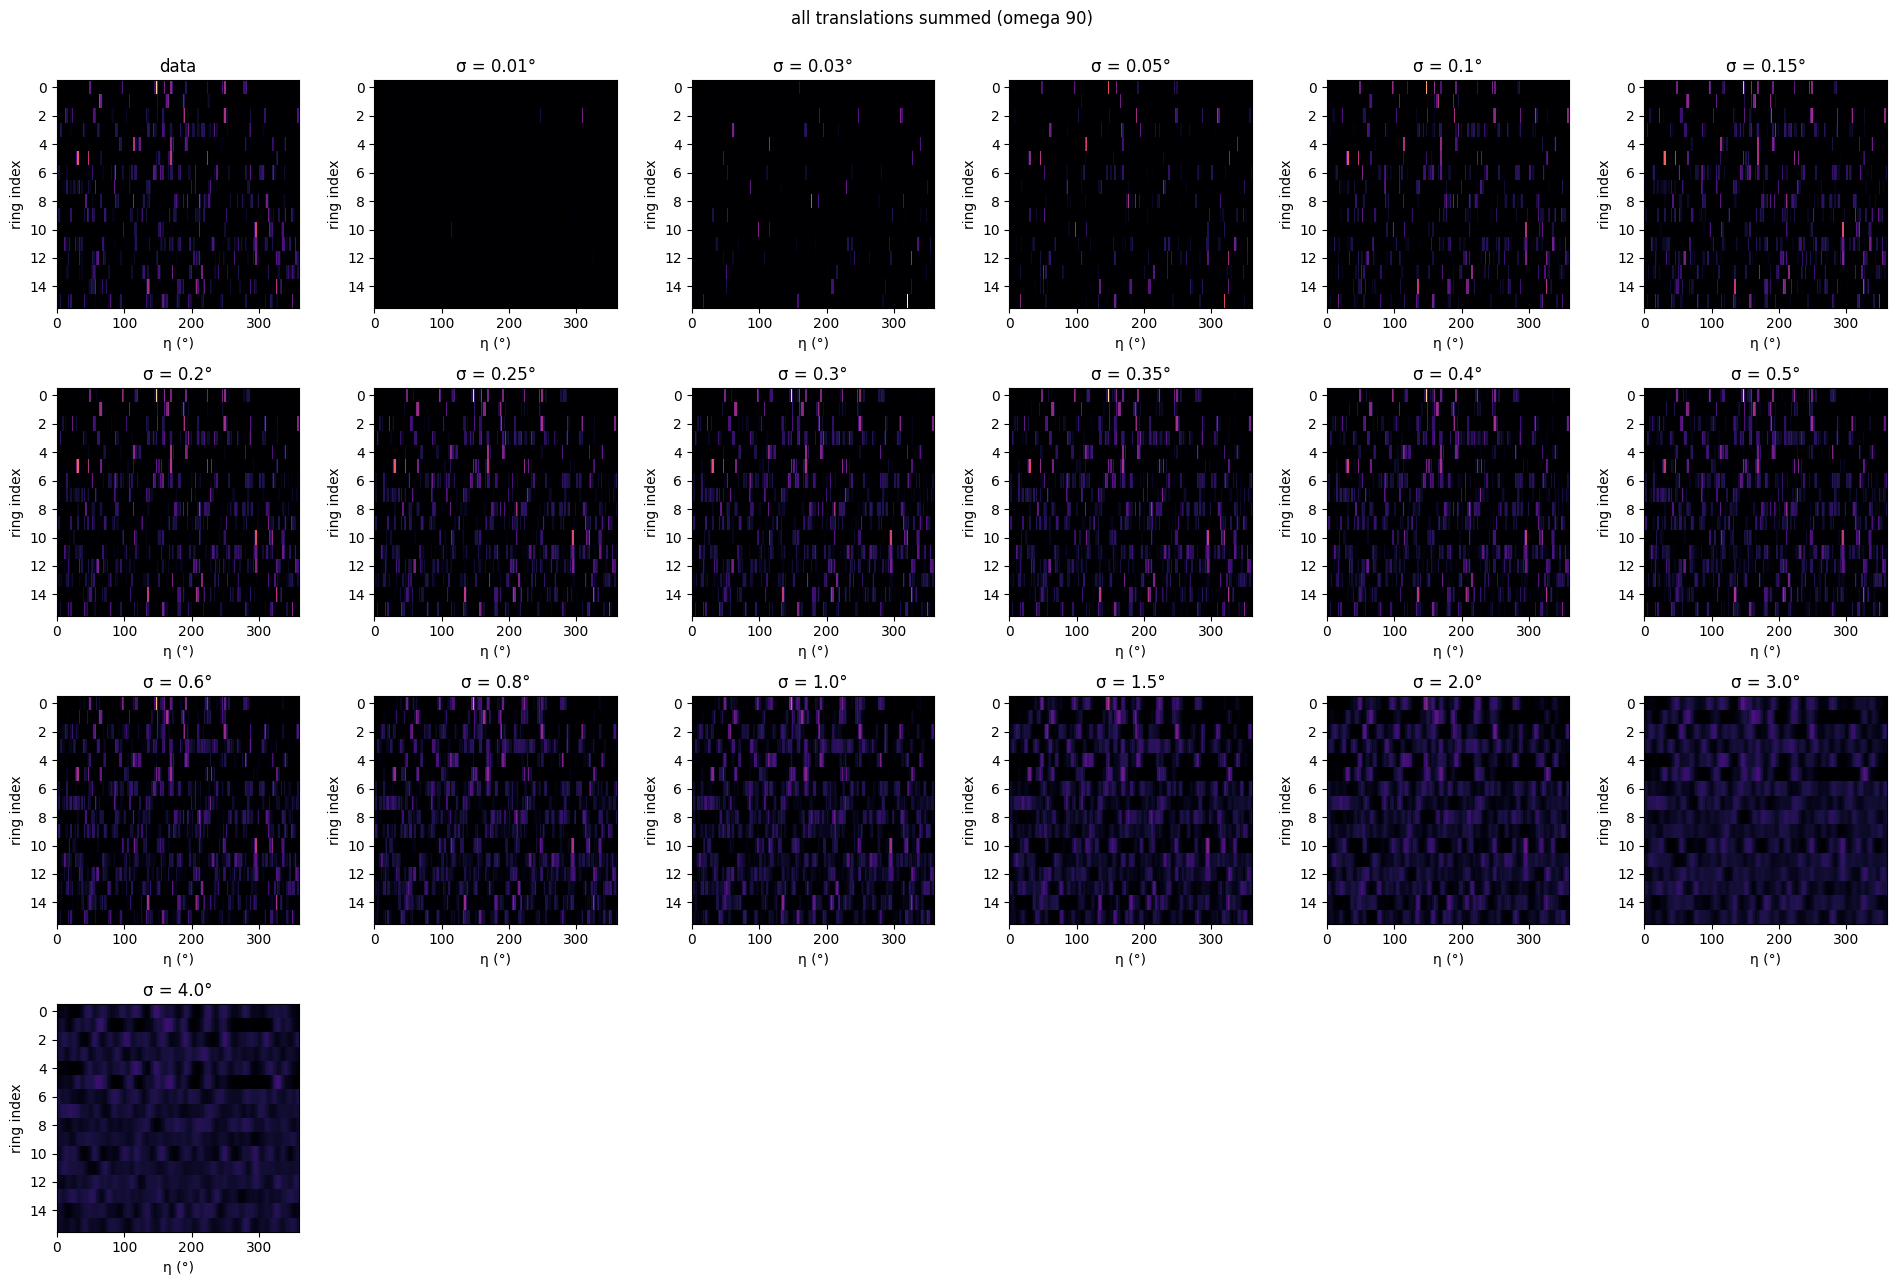

In [13]:
data_sl, pred_sl = stability.prediction_slices(files, SAMPLE, OMEGA_INDEX, TRANSLATION_INDEX, OUT)
n_eta, n_rings = data_sl["frame"].shape
eta = (np.arange(n_eta) + 0.5) * 360 / n_eta
masked = data_sl["eta_weight"] == 0

rows = [("frame", f"single frame (omega {OMEGA_INDEX}, translation {TRANSLATION_INDEX})"),
        ("summed", f"all translations summed (omega {OMEGA_INDEX})")]
for key, title in rows:
    panels = [("data", data_sl[key])] + [(label, p[key]) for label, p in pred_sl.items()]
    vmax = max(img.max() for _, img in panels)
    fig, ax = panel_axes(len(panels), ncols=6, size=3.2)
    for a, (label, img) in zip(ax, panels):
        a.axis("on")
        a.imshow(img.T, aspect="auto", extent=[0, 360, n_rings - 0.5, -0.5], interpolation="nearest",
                 cmap="magma", norm=PowerNorm(IMAGE_GAMMA, vmin=0, vmax=vmax))
        a.set_title(label)
        a.set_xlabel("η (°)")
        a.set_ylabel("ring index")
    fig.suptitle(title, y=1.0)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT, f"data_vs_prediction_{key}.png"), dpi=100, bbox_inches="tight")
    plt.show()

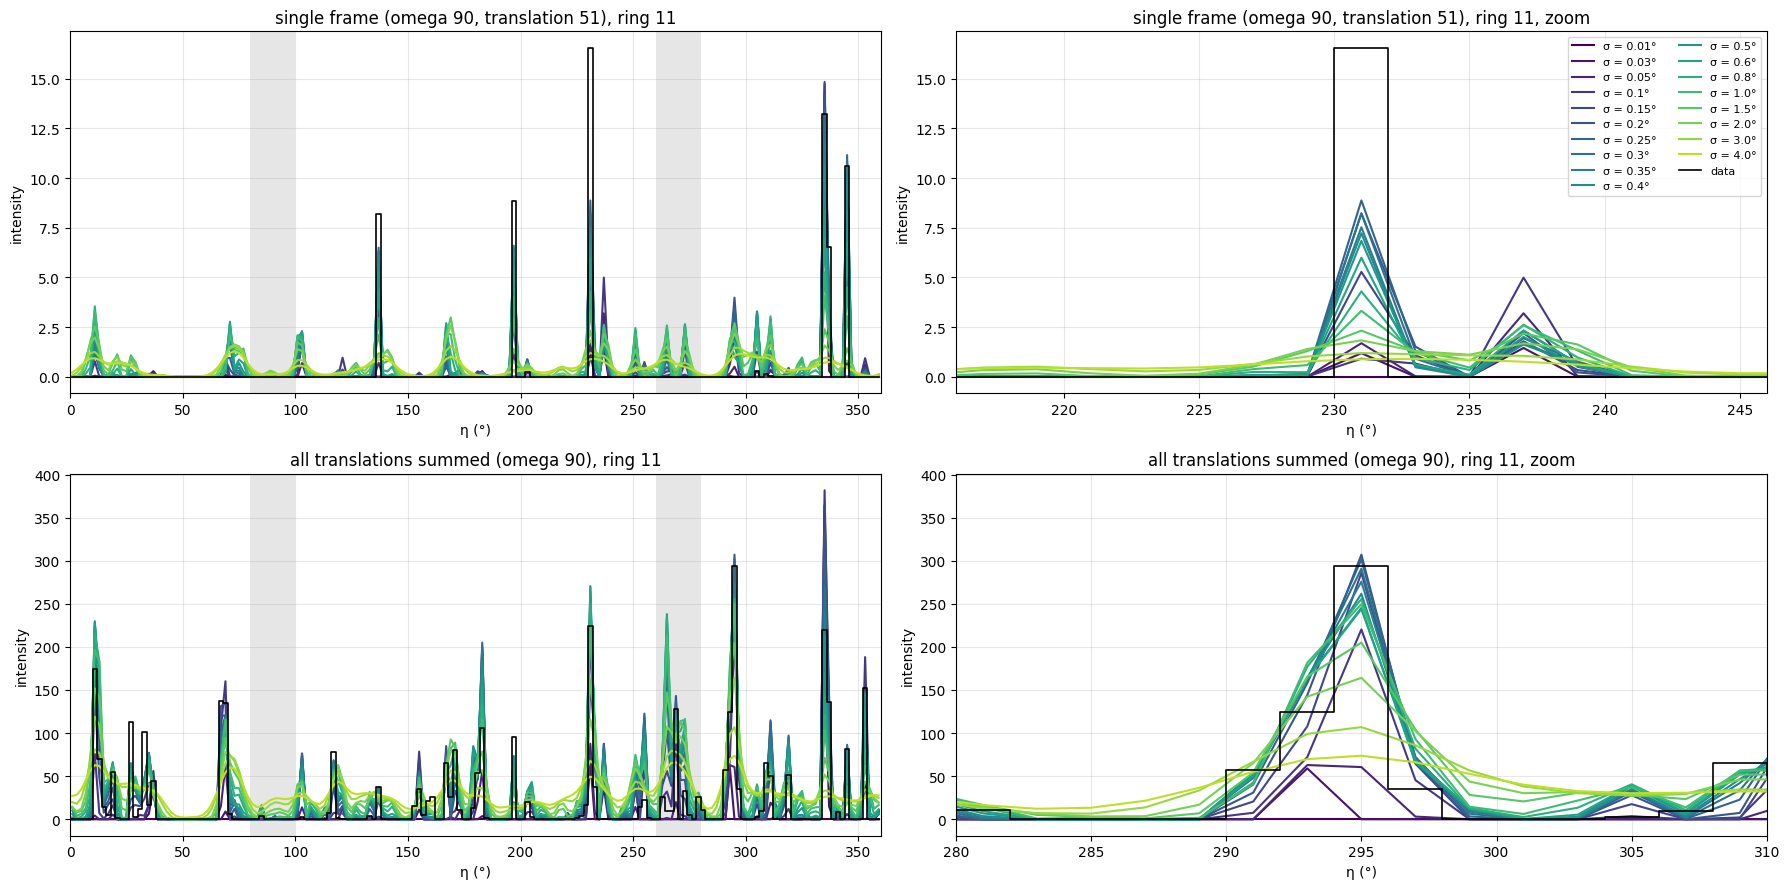

In [14]:
ring = RING if RING is not None else int(np.argmax(data_sl["frame"].sum(axis=0)))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(pred_sl)))
fig, ax = plt.subplots(2, 2, figsize=(18, 9))
for r, (key, title) in enumerate(rows):
    d = data_sl[key][:, ring]
    peak = eta[np.argmax(np.where(masked, -np.inf, d))]
    for c, xlim in enumerate([(0, 360), (peak - ZOOM_ETA, peak + ZOOM_ETA)]):
        a = ax[r, c]
        for i in np.where(masked)[0]:
            a.axvspan(i * 360 / n_eta, (i + 1) * 360 / n_eta, color="0.9", lw=0)
        for (label, p), col in zip(pred_sl.items(), colors):
            a.plot(eta, p[key][:, ring], color=col, lw=1.5, label=label)
        a.step(eta, d, where="mid", color="k", lw=1.2, label="data")
        a.set_xlim(xlim)
        a.set_xlabel("η (°)")
        a.set_ylabel("intensity")
        a.set_title(title.replace("\n", " ") + f", ring {ring}" + (", zoom" if c else ""))
        a.grid(alpha=0.3)
ax[0, 1].legend(fontsize=8, ncol=2)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "data_vs_prediction_profiles.png"), dpi=100, bbox_inches="tight")
plt.show()

## Tables

In [15]:
misori_table.to_csv(os.path.join(OUT, "misorientation_statistics.csv"))
boundary_table.to_csv(os.path.join(OUT, "boundary_statistics.csv"), index=False)
pair_mean.to_csv(os.path.join(OUT, "pairwise_mean_misorientation.csv"))
pair_median.to_csv(os.path.join(OUT, "pairwise_median_misorientation.csv"))
coeff_diff.to_csv(os.path.join(OUT, "pairwise_coefficient_difference.csv"))
runs.to_csv(os.path.join(OUT, "runs.csv"))
print("\n".join(sorted(f for f in os.listdir(OUT) if f.endswith((".png", ".csv")))))

boundaries.png
boundary_statistics.csv
boundary_statistics.png
consecutive_misorientation.png
convergence.png
data_vs_prediction_frame.png
data_vs_prediction_profiles.png
data_vs_prediction_summed.png
ipf_z.png
misorientation.png
misorientation_statistics.csv
misorientation_statistics.png
pairwise_coefficient_difference.csv
pairwise_differences.png
pairwise_mean_misorientation.csv
pairwise_median_misorientation.csv
runs.csv
